# Análise de E-commerce — Olist

**Autor:** Jonatas Magalhães · [LinkedIn](https://www.linkedin.com/in/jonatasmag/) · [Portfólio](https://jonatasmag.github.io)

Análise de **110 mil itens vendidos** em um marketplace brasileiro, de janeiro de 2017 a agosto de 2018. O projeto cobre o ciclo completo: dados transacionais (OLTP) → ETL em Python → modelo estrela → consultas SQL → conclusões de negócio.

### Perguntas de negócio
1. Quanto a operação faturou e qual é o ticket médio?
2. Onde está concentrado o faturamento?
3. Quais categorias sustentam o negócio?
4. Como o faturamento evoluiu e o que aconteceu nos picos?
5. A logística entrega no prazo — e onde ela falha?

## 1. Preparação

O ETL fica em `src/etl.py` (reutilizável fora do notebook). Aqui ele é importado, e o modelo estrela é carregado num banco **SQLite em memória** — nativo do Python, sem instalar nada.

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import etl  # noqa: E402

FIGURAS = RAIZ / "reports" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

In [2]:
# Identidade visual dos gráficos (mesma do portfólio)
AZUL, AZUL_CLARO, CINZA, TINTA, TINTA_SUAVE = "#0d5a92", "#b9d3e4", "#c9d3db", "#142b3d", "#5e7080"
plt.rcParams.update({
    "font.family": ["Inter", "DejaVu Sans"], "font.size": 10.5,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA_SUAVE, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.titlecolor": TINTA, "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6ecf0", "grid.linewidth": 0.8,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE, "figure.dpi": 110,
    "savefig.dpi": 160, "savefig.bbox": "tight", "figure.facecolor": "white",
    "text.parse_math": False, "axes.axisbelow": True,
})

def reais(v, casas=0):
    return f"R$ {v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def salvar(fig, nome):
    fig.savefig(FIGURAS / f"{nome}.png")

## 2. ETL e modelo estrela

**Regras aplicadas no tratamento:**
- Somente pedidos com status `delivered` (vendas efetivadas).
- Recorte de **jan/2017 a ago/2018**: 2016 tem apenas 267 pedidos entregues (operação inicial, com meses de 1 pedido) e distorceria as séries.
- Remoção de duplicidades; categorias sem nome viram `Sem categoria`.
- Dimensão tempo como **calendário contínuo** (um dia por linha), com chave inteligente `AAAAMMDD`.
- Duas tabelas fato com granularidades diferentes: **`fato_vendas`** (1 linha por item) e **`fato_entregas`** (1 linha por pedido) — assim, prazo e atraso não são contados várias vezes em pedidos com mais de um item.
- Validações de integridade referencial ao final do ETL (`assert`).

```
dim_cliente ─┐
dim_produto ─┼── fato_vendas     (grão: item vendido)
dim_tempo  ──┤
             └── fato_entregas   (grão: pedido entregue)
```

In [3]:
modelo = etl.construir_modelo()
etl.carregar(modelo)  # exporta data/processed/*.csv para o Power BI

pd.DataFrame(
    {"linhas": {nome: len(t) for nome, t in modelo.items()},
     "colunas": {nome: t.shape[1] for nome, t in modelo.items()}}
)

,linhas,colunas
dim_cliente,99441,5
dim_produto,32951,4
dim_tempo,608,7
fato_vendas,109880,9
fato_entregas,96203,6


In [4]:
con = sqlite3.connect(":memory:")
for nome, tabela in modelo.items():
    tabela.to_sql(nome, con, index=False)

def consulta(arquivo, mostrar_sql=True):
    """Executa um arquivo da pasta sql/ e devolve o resultado como DataFrame."""
    sql = (RAIZ / "sql" / arquivo).read_text(encoding="utf-8")
    if mostrar_sql:
        print(sql)
    return pd.read_sql(sql, con)

## 3. Visão geral

In [5]:
kpis = consulta("01_kpis_gerais.sql")
kpis

-- Visão geral do negócio no período analisado (jan/2017 a ago/2018)
SELECT
    ROUND(SUM(f.valor_total), 2)                                  AS faturamento_total,
    COUNT(DISTINCT f.pedido_id)                                   AS pedidos,
    COUNT(DISTINCT c.cliente_unico_id)                            AS clientes_unicos,
    ROUND(SUM(f.valor_total) / COUNT(DISTINCT f.pedido_id), 2)    AS ticket_medio,
    ROUND(100.0 * SUM(f.valor_frete) / SUM(f.valor_total), 1)     AS pct_frete_no_faturamento
FROM fato_vendas f
JOIN dim_cliente c ON c.cliente_sk = f.cliente_sk;



,faturamento_total,pedidos,clientes_unicos,ticket_medio,pct_frete_no_faturamento
0,"15.373.120,01",96211,93104,"159,79","14,30"


In [6]:
k = kpis.iloc[0]
def pct(v, casas=1):
    return f"{v:.{casas}f}%".replace(".", ",")

def inteiro(v):
    return f"{v:,.0f}".replace(",", ".")

print(f"Faturamento: {reais(k.faturamento_total)}  |  Pedidos: {inteiro(k.pedidos)}  |  "
      f"Clientes: {inteiro(k.clientes_unicos)}  |  Ticket médio: {reais(k.ticket_medio, 2)}  |  "
      f"Frete: {pct(k.pct_frete_no_faturamento)} do faturamento")

Faturamento: R$ 15.373.120  |  Pedidos: 96.211  |  Clientes: 93.104  |  Ticket médio: R$ 159,79  |  Frete: 14,3% do faturamento


## 4. Onde está o faturamento

In [7]:
uf = consulta("02_faturamento_por_estado.sql")
uf.head(10)

-- Faturamento por estado, com participação no total e participação acumulada (Pareto)
WITH por_uf AS (
    SELECT
        c.uf,
        SUM(f.valor_total)          AS faturamento,
        COUNT(DISTINCT f.pedido_id) AS pedidos
    FROM fato_vendas f
    JOIN dim_cliente c ON c.cliente_sk = f.cliente_sk
    GROUP BY c.uf
)
SELECT
    uf,
    ROUND(faturamento, 2)                                                        AS faturamento,
    pedidos,
    ROUND(100.0 * faturamento / SUM(faturamento) OVER (), 1)                     AS pct_total,
    ROUND(100.0 * SUM(faturamento) OVER (ORDER BY faturamento DESC)
                / SUM(faturamento) OVER (), 1)                                   AS pct_acumulado
FROM por_uf
ORDER BY faturamento DESC;



,uf,faturamento,pedidos,pct_total,pct_acumulado
0,SP,"5.755.999,76",40406,"37,40","37,40"
1,RJ,"2.046.357,64",12310,"13,30","50,80"
2,MG,"1.813.954,27",11319,"11,80","62,60"
3,RS,"858.574,68",5328,"5,60","68,10"
4,PR,"779.214,08",4903,"5,10","73,20"
5,SC,"592.627,06",3537,"3,90","77,10"
6,BA,"590.816,80",3253,"3,80","80,90"
7,DF,"344.923,24",2074,"2,20","83,10"
8,GO,"333.156,23",1950,"2,20","85,30"
9,ES,"316.666,12",1992,"2,10","87,40"


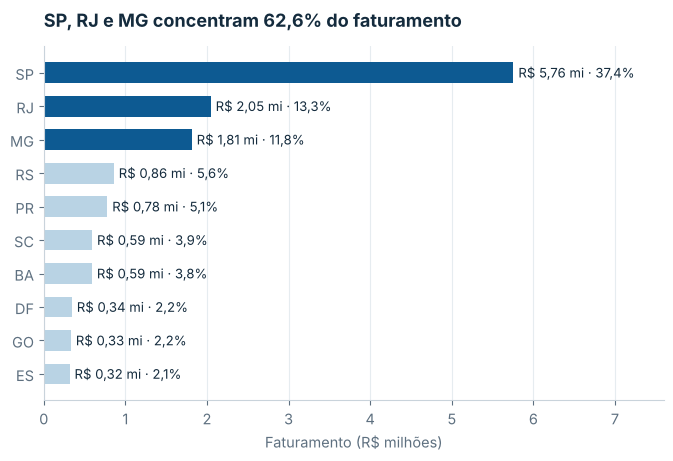

In [8]:
top = uf.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.6))
cores = [AZUL if u in ("SP", "RJ", "MG") else AZUL_CLARO for u in top.uf]
ax.barh(top.uf, top.faturamento / 1e6, color=cores, height=0.62)
for y, (v, p) in enumerate(zip(top.faturamento, top.pct_total)):
    ax.text(v / 1e6 + 0.06, y, f"{reais(v/1e6, 2)} mi · {p:.1f}%".replace(".", ","), va="center", fontsize=9.5, color=TINTA)
ax.set_title("SP, RJ e MG concentram 62,6% do faturamento")
ax.set_xlabel("Faturamento (R$ milhões)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, top.faturamento.max() / 1e6 * 1.32)
salvar(fig, "01_faturamento_por_estado")
plt.show()

**Leitura:** a operação é fortemente concentrada no Sudeste — três estados somam 62,6% da receita, e sete estados chegam a 80,9% (regra de Pareto). Qualquer problema logístico em SP, RJ ou MG afeta mais da metade do negócio.

In [9]:
ticket = consulta("04_ticket_medio_por_estado.sql")
ticket

-- Ticket médio por estado (somente estados com amostra relevante: 500+ pedidos)
-- O ticket é calculado por PEDIDO, não por item, para não distorcer pedidos com vários itens.
WITH pedidos AS (
    SELECT
        f.pedido_id,
        c.uf,
        SUM(f.valor_total) AS valor_pedido,
        SUM(f.valor_frete) AS frete_pedido
    FROM fato_vendas f
    JOIN dim_cliente c ON c.cliente_sk = f.cliente_sk
    GROUP BY f.pedido_id, c.uf
)
SELECT
    uf,
    COUNT(*)                                            AS pedidos,
    ROUND(AVG(valor_pedido), 2)                         AS ticket_medio,
    ROUND(AVG(frete_pedido), 2)                         AS frete_medio,
    ROUND(100.0 * SUM(frete_pedido) / SUM(valor_pedido), 1) AS pct_frete
FROM pedidos
GROUP BY uf
HAVING COUNT(*) >= 500
ORDER BY ticket_medio DESC;



,uf,pedidos,ticket_medio,frete_medio,pct_frete
0,PB,516,"266,98","48,89","18,30"
1,PA,942,"223,72","39,66","17,70"
2,CE,1273,"207,82","36,48","17,60"
3,MA,713,"205,90","42,78","20,80"
4,MT,885,"204,66","32,74","16,00"
5,PE,1587,"193,72","35,78","18,50"
6,MS,701,"191,68","27,02","14,10"
7,BA,3253,"181,62","29,97","16,50"
8,GO,1950,"170,85","26,27","15,40"
9,SC,3537,"167,55","24,84","14,80"


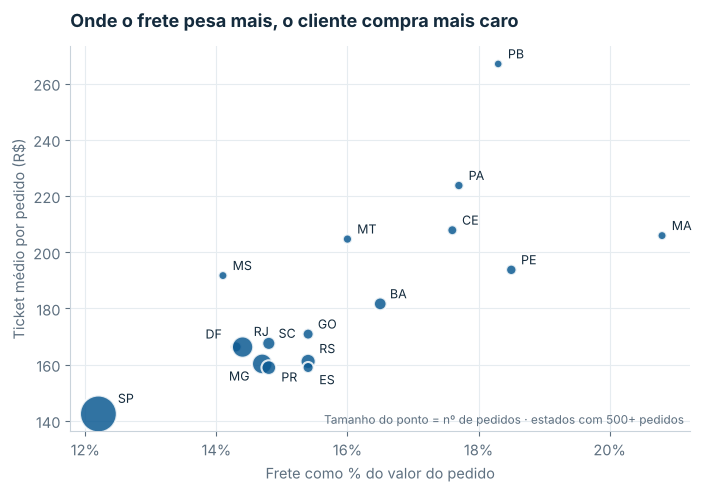

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ticket.pct_frete, ticket.ticket_medio, s=ticket.pedidos / 60 + 30, color=AZUL, alpha=0.85,
           edgecolor="white", linewidth=1.5, zorder=3)
desloc = {"DF": (-22, 6), "RJ": (8, 8), "MG": (-24, -12), "PR": (9, -10), "RS": (8, 6), "ES": (8, -12), "SP": (14, 8)}
for _, r in ticket.iterrows():
    ax.annotate(r.uf, (r.pct_frete, r.ticket_medio), xytext=desloc.get(r.uf, (7, 4)),
                textcoords="offset points", fontsize=9, color=TINTA)
ax.set_title("Onde o frete pesa mais, o cliente compra mais caro")
ax.set_xlabel("Frete como % do valor do pedido")
ax.set_ylabel("Ticket médio por pedido (R$)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.text(0.99, 0.02, "Tamanho do ponto = nº de pedidos · estados com 500+ pedidos", transform=ax.transAxes,
        ha="right", fontsize=8.5, color=TINTA_SUAVE)
salvar(fig, "02_ticket_vs_frete")
plt.show()

**Leitura:** nos estados do Norte e Nordeste o ticket médio é bem maior (PB: R$ 266,98 contra SP: R$ 142,45), mas o frete chega a 20,8% do pedido (MA), contra 12,2% em SP. O frete funciona como **barreira de entrada**: só compensa comprar itens caros. Há espaço para crescer em pedidos de menor valor nessas regiões com frete subsidiado ou um centro de distribuição regional.

## 5. Categorias

In [11]:
cat = consulta("03_top10_categorias.sql")
cat

-- 10 categorias com maior faturamento
SELECT
    p.categoria,
    ROUND(SUM(f.valor_total), 2)                                         AS faturamento,
    COUNT(*)                                                             AS itens_vendidos,
    ROUND(AVG(f.valor_produto), 2)                                       AS preco_medio,
    ROUND(100.0 * SUM(f.valor_total) / (SELECT SUM(valor_total) FROM fato_vendas), 1) AS pct_total
FROM fato_vendas f
JOIN dim_produto p ON p.produto_sk = f.produto_sk
GROUP BY p.categoria
ORDER BY faturamento DESC
LIMIT 10;



,categoria,faturamento,itens_vendidos,preco_medio,pct_total
0,Beleza e saúde,"1.407.759,78",9422,"130,50","9,20"
1,Relógios e presentes,"1.261.539,41",5855,"198,71","8,20"
2,"Cama, mesa e banho","1.224.602,68",10945,"93,46","8,00"
3,Esporte e lazer,"1.115.766,15",8414,"113,24","7,30"
4,Informática e acessórios,"1.031.861,93",7632,"116,36","6,70"
5,Móveis e decoração,"873.430,57",8095,"87,24","5,70"
6,Utilidades domésticas,"756.849,71",6783,"90,57","4,90"
7,Presentes criativos,"690.444,01",3711,"164,15","4,50"
8,Automotivo,"668.103,48",4132,"139,84","4,30"
9,Ferramentas e jardim,"565.680,49",4263,"110,05","3,70"


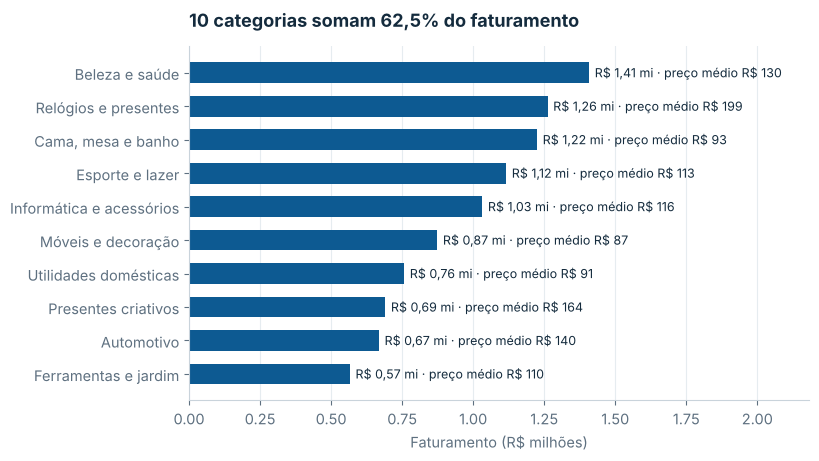

In [12]:
c = cat.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(c.categoria, c.faturamento / 1e6, color=AZUL, height=0.62)
for y, (v, pm) in enumerate(zip(c.faturamento, c.preco_medio)):
    ax.text(v / 1e6 + 0.02, y, f"{reais(v/1e6, 2)} mi · preço médio {reais(pm)}", va="center", fontsize=9, color=TINTA)
ax.set_title(f"10 categorias somam {cat.pct_total.sum():.1f}% do faturamento".replace(".", ","))
ax.set_xlabel("Faturamento (R$ milhões)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, c.faturamento.max() / 1e6 * 1.55)
salvar(fig, "03_top_categorias")
plt.show()

**Leitura:** o faturamento é bem distribuído — nenhuma categoria passa de 10%, o que reduz o risco do negócio. Há dois perfis claros: **volume** (Cama, mesa e banho: mais itens vendidos, preço médio de R$ 93) e **valor** (Relógios e presentes: quase metade dos itens, mas preço médio de R$ 199). Estratégias de estoque e de marketing devem ser diferentes para cada perfil.

## 6. Evolução mensal

In [13]:
mensal = consulta("05_evolucao_mensal.sql")
mensal

-- Evolução mensal do faturamento, com variação contra o mês anterior
WITH mensal AS (
    SELECT
        t.ano_mes,
        SUM(f.valor_total)          AS faturamento,
        COUNT(DISTINCT f.pedido_id) AS pedidos
    FROM fato_vendas f
    JOIN dim_tempo t ON t.tempo_sk = f.tempo_sk
    GROUP BY t.ano_mes
)
SELECT
    ano_mes,
    ROUND(faturamento, 2) AS faturamento,
    pedidos,
    ROUND(faturamento / pedidos, 2) AS ticket_medio,
    ROUND(100.0 * (faturamento - LAG(faturamento) OVER (ORDER BY ano_mes))
                / LAG(faturamento) OVER (ORDER BY ano_mes), 1) AS variacao_mes_pct
FROM mensal
ORDER BY ano_mes;



,ano_mes,faturamento,pedidos,ticket_medio,variacao_mes_pct
0,2017-01,"127.482,37",750,"169,98",NaN
1,2017-02,"271.239,32",1653,"164,09","112,80"
2,2017-03,"414.330,95",2546,"162,74","52,80"
3,2017-04,"390.812,40",2303,"169,70","-5,70"
4,2017-05,"566.851,40",3546,"159,86","45,00"
5,2017-06,"490.050,37",3135,"156,32","-13,50"
6,2017-07,"566.299,08",3872,"146,25","15,60"
7,2017-08,"645.832,36",4193,"154,03","14,00"
8,2017-09,"701.077,49",4150,"168,93","8,60"
9,2017-10,"751.117,01",4478,"167,73","7,10"


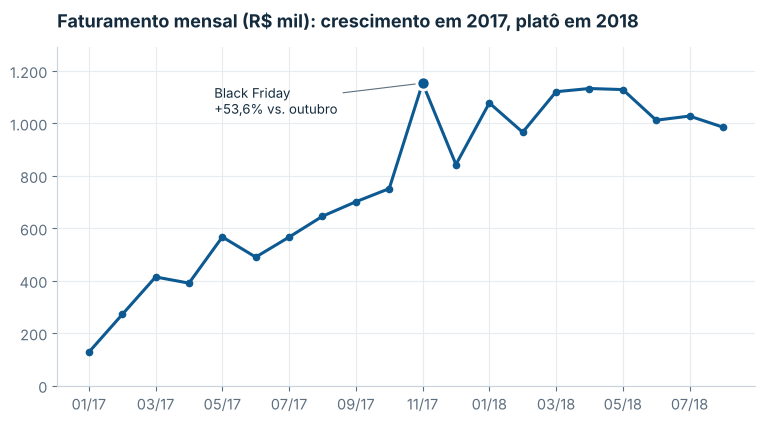

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = range(len(mensal))
ax.plot(x, mensal.faturamento / 1e3, color=AZUL, linewidth=2.2, marker="o", markersize=4.5, zorder=3)
bf = mensal.index[mensal.ano_mes == "2017-11"][0]
ax.scatter([bf], [mensal.faturamento[bf] / 1e3], s=90, color=AZUL, edgecolor="white", linewidth=2, zorder=4)
ax.annotate("Black Friday\n+53,6% vs. outubro", (bf, mensal.faturamento[bf] / 1e3), xytext=(-150, -22),
            textcoords="offset points", fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle="-", color=TINTA_SUAVE, lw=0.8))
ax.set_xticks(list(x)[::2], [m[5:] + "/" + m[2:4] for m in mensal.ano_mes[::2]])
ax.set_title("Faturamento mensal (R$ mil): crescimento em 2017, platô em 2018")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))
ax.set_ylim(0, mensal.faturamento.max() / 1e3 * 1.12)
salvar(fig, "04_evolucao_mensal")
plt.show()

In [15]:
mensal["ano"] = mensal.ano_mes.str[:4]
mensal["mes"] = mensal.ano_mes.str[5:].astype(int)
comparavel = mensal[mensal.mes <= 8].groupby("ano").faturamento.sum()
crescimento = comparavel["2018"] / comparavel["2017"] - 1
print(f"Jan–Ago/2017: {reais(comparavel['2017'])}  |  Jan–Ago/2018: {reais(comparavel['2018'])}  |  "
      f"Crescimento: {pct(crescimento * 100)}")

Jan–Ago/2017: R$ 3.472.898  |  Jan–Ago/2018: R$ 8.451.585  |  Crescimento: 143,4%


**Leitura:** comparando períodos equivalentes (jan–ago), o faturamento de 2018 foi **2,4 vezes** o de 2017. Mas o crescimento parou: desde janeiro de 2018 a receita oscila em torno de R$ 1,0–1,1 milhão por mês. O ticket médio ficou estável (R$ 146–170), ou seja, o crescimento de 2017 veio de **mais pedidos**, não de pedidos maiores.

## 7. Logística: prazo e atraso

In [16]:
entregas = consulta("06_entregas_por_estado.sql")
entregas

-- Desempenho logístico por estado: prazo real, prazo prometido e taxa de atraso
SELECT
    c.uf,
    COUNT(*)                                     AS pedidos_entregues,
    ROUND(AVG(e.prazo_entrega_dias), 1)          AS prazo_medio_dias,
    ROUND(AVG(e.prazo_prometido_dias), 1)        AS prazo_prometido_dias,
    ROUND(100.0 * AVG(e.entregue_com_atraso), 1) AS pct_atraso
FROM fato_entregas e
JOIN dim_cliente c ON c.cliente_sk = e.cliente_sk
GROUP BY c.uf
HAVING COUNT(*) >= 100
ORDER BY prazo_medio_dias DESC;



,uf,pedidos_entregues,prazo_medio_dias,prazo_prometido_dias,pct_atraso
0,AM,145,"26,40","45,90","2,80"
1,AL,396,"24,50","33,10","21,50"
2,PA,942,"23,80","37,70","11,30"
3,MA,713,"21,50","30,90","17,50"
4,SE,332,"21,40","31,20","15,40"
5,CE,1273,"21,20","31,80","13,80"
6,PB,516,"20,40","33,60","10,50"
7,RO,243,"19,40","39,40","2,90"
8,PI,475,"19,40","30,60","13,90"
9,BA,3253,"19,30","30,00","12,20"


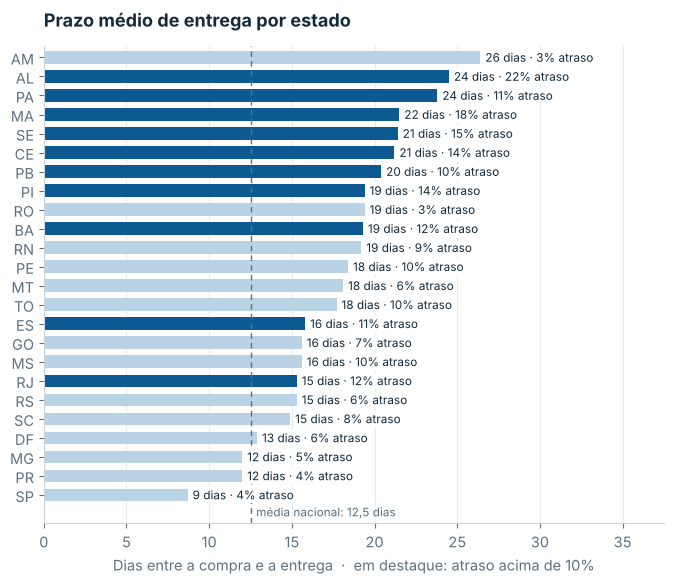

In [17]:
e = entregas.sort_values("prazo_medio_dias")
media_nacional = modelo["fato_entregas"].prazo_entrega_dias.mean()
fig, ax = plt.subplots(figsize=(8, 6.2))
cores = [AZUL if p > 10 else AZUL_CLARO for p in e.pct_atraso]
ax.barh(e.uf, e.prazo_medio_dias, color=cores, height=0.66)
for y, (d, a) in enumerate(zip(e.prazo_medio_dias, e.pct_atraso)):
    ax.text(d + 0.3, y, f"{d:.0f} dias · {a:.0f}% atraso", va="center", fontsize=8.5, color=TINTA,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6), zorder=4)
ax.axvline(media_nacional, color=TINTA_SUAVE, linestyle=(0, (4, 3)), linewidth=1)
ax.text(media_nacional + 0.3, -0.9, f"média nacional: {media_nacional:.1f} dias".replace(".", ","),
        fontsize=8.5, color=TINTA_SUAVE, va="center")
ax.set_ylim(-1.5, len(e) - 0.4)
ax.set_title("Prazo médio de entrega por estado")
ax.set_xlabel("Dias entre a compra e a entrega  ·  em destaque: atraso acima de 10%")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, e.prazo_medio_dias.max() * 1.42)
salvar(fig, "05_prazo_por_estado")
plt.show()

In [18]:
atraso = consulta("07_atraso_por_mes.sql")
atraso

-- Taxa de atraso ao longo do tempo: a operação aguentou os picos de demanda?
SELECT
    t.ano_mes,
    COUNT(*)                                     AS pedidos_entregues,
    ROUND(100.0 * AVG(e.entregue_com_atraso), 1) AS pct_atraso,
    ROUND(AVG(e.prazo_entrega_dias), 1)          AS prazo_medio_dias
FROM fato_entregas e
JOIN dim_tempo t ON t.tempo_sk = e.tempo_sk
GROUP BY t.ano_mes
ORDER BY t.ano_mes;



,ano_mes,pedidos_entregues,pct_atraso,prazo_medio_dias
0,2017-01,750,"2,90","12,60"
1,2017-02,1653,"3,00","13,20"
2,2017-03,2546,"4,60","13,00"
3,2017-04,2303,"6,60","14,90"
4,2017-05,3545,"3,00","11,30"
5,2017-06,3135,"3,00","12,00"
6,2017-07,3872,"2,80","11,60"
7,2017-08,4193,"2,90","11,10"
8,2017-09,4150,"4,40","11,90"
9,2017-10,4478,"4,20","11,90"


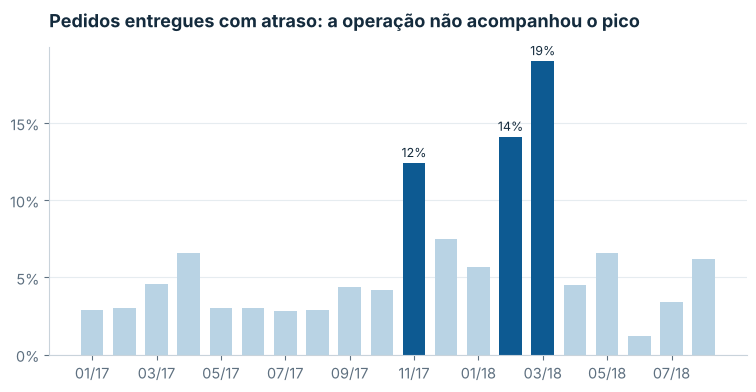

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(atraso))
cores = [AZUL if p >= 10 else AZUL_CLARO for p in atraso.pct_atraso]
ax.bar(x, atraso.pct_atraso, color=cores, width=0.7)
for i, p in enumerate(atraso.pct_atraso):
    if p >= 10:
        ax.text(i, p + 0.4, f"{p:.0f}%", ha="center", fontsize=9, color=TINTA)
ax.set_xticks(list(x)[::2], [m[5:] + "/" + m[2:4] for m in atraso.ano_mes[::2]])
ax.yaxis.set_major_locator(mtick.MultipleLocator(5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("Pedidos entregues com atraso: a operação não acompanhou o pico")
ax.grid(axis="x", visible=False)
salvar(fig, "06_atraso_por_mes")
plt.show()

**Leitura:**
- **Distância pesa:** SP recebe em 8,7 dias; AL leva 24,5 dias e atrasa 21,5% dos pedidos.
- **RJ é a anomalia mais relevante:** segundo maior mercado (13,3% do faturamento), mas com 12,1% de atraso — quase 3 vezes a taxa de SP e MG, também no Sudeste. É o primeiro ponto a investigar (transportadora? áreas de restrição de entrega? centro de distribuição?).
- **O pico cobrou a conta depois:** após a Black Friday o atraso saltou de 4% para 12% e chegou a **19% em março de 2018**, só voltando ao normal em junho. A operação cresceu mais rápido que a capacidade logística.
- O prazo **prometido** é folgado (cerca de 2 vezes o prazo real), o que mascara a percepção de atraso — mas também pode estar afastando compradores na página do produto.

## 8. Conclusões e recomendações

| # | Achado | Recomendação |
|---|---|---|
| 1 | SP, RJ e MG = 62,6% da receita | Priorizar SLA logístico e estoque nesses três estados |
| 2 | RJ atrasa 12,1% (vs. 4,5% em SP) | Auditar transportadoras e rotas do RJ — maior ganho por esforço |
| 3 | Atraso chegou a 19% após o pico de vendas | Planejar capacidade antes de datas sazonais (Black Friday, Natal) |
| 4 | Frete = 18–21% do pedido no NE | Testar frete subsidiado / CD regional para destravar tickets menores |
| 5 | Faturamento estável desde jan/2018 | Crescimento agora depende de recompra e novos mercados, não só de tráfego |

### Limitações
- Dados públicos e anonimizados da Olist; valores sem correção pela inflação.
- Não há custo de produto nem de frete pago à transportadora — a análise é de **receita**, não de margem.

**Fonte dos dados:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (licença CC BY-NC-SA 4.0).